# Retrieval-augmented forecasting: historical analogs as a knowledge base

"What happened the last twenty times the tape looked like this?" Analog
forecasting is one of the oldest ideas in the business. Retrieval-augmented
generation is the same idea with modern parts: encode the query, search a
knowledge base of past cases, condition the prediction on what came back.
TS-RAG ([arXiv:2503.07649](https://arxiv.org/abs/2503.07649)) applies it to
time-series foundation models and reports gains without any fine-tuning.

A RAG system has three pieces. An *encoder* turns a window into a vector. A
*knowledge base* stores those vectors next to the outcome that followed. A
*retriever* finds the nearest neighbours of a query vector.

On time series the knowledge base is itself a time series, and that is where
the trouble starts. A neighbour is only usable if its outcome was already
known when you asked. Get that wrong and the retriever hands you the answer.
We build the whole pipeline in h5i-db and then measure the leak, which turns
out to be worth an information coefficient of 1.00.

1. encode 20-day return windows into fixed-size vectors,
2. store them in h5i-db as an ordinary column, timestamped by *when the
   outcome became knowable*,
3. retrieve with `array_distance` through the DataFrame builder,
4. plot the analogs and their continuations,
5. price the leakage: four retrieval rules, four very different backtests,
6. pin the knowledge base to a version, because event time is only one of the
   two clocks.

## Terms used here

| term             | meaning |
| ---------------- | --- |
| RAG              | retrieval-augmented generation: search a knowledge base, then condition on what came back |
| encoder          | the step that turns a window of data into a fixed-size vector |
| embedding        | that vector, stored here as an ordinary list column |
| knowledge base   | the stored vectors, each next to the outcome that followed it |
| retriever        | the search that finds the nearest neighbours of a query vector |
| `array_distance` | the SQL function that measures distance between two vectors |
| leakage          | a neighbour whose outcome was not yet knowable, so the retriever hands you the answer |
| IC               | information coefficient: correlation between a forecast and the return that followed |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, sql_expr
import cookbook_utils as cu

LOOKBACK, HORIZON, TOP_K = 20, 5, 25

db = h5i_db.Database(cu.fresh_db("alpha_rag_forecasting"), create=True)

## 1. The corpus

`cu.fetch_daily` returns one row per symbol per session for the cached 30-name
S&P sample, eight and a half years of it.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | session close, ascending |
| `symbol` | `string` | ticker |
| `open`, `high`, `low`, `close` | `float64` | session prices |
| `adj_close` | `float64` | split- and dividend-adjusted close |
| `volume` | `int64` | session volume |

We keep `adj_close` and land it as the corpus table. Everything else in this
recipe is derived from it, so it is the one thing that has to be right.

In [2]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01").to_pandas()
print(f"{len(daily):,} rows x {daily.shape[1]} columns, {daily['symbol'].nunique()} symbols")
daily.head()

64,020 rows x 8 columns, 30 symbols


,ts,symbol,open,high,low,close,adj_close,volume
0,2018-01-02 20:00:00+00:00,AAPL,42.540001,43.075001,42.314999,43.064999,40.267075,102223600
1,2018-01-02 20:00:00+00:00,NVDA,4.894500,4.987500,4.862500,4.983750,4.922529,355616000
2,2018-01-02 20:00:00+00:00,GE,84.251045,86.215950,84.011429,86.168022,80.953125,16185981
3,2018-01-02 20:00:00+00:00,AMZN,58.599998,59.500000,58.525501,59.450500,59.450500,53890000
4,2018-01-02 20:00:00+00:00,IBM,147.705551,148.001907,146.787766,147.466537,102.657249,4395815


In [3]:
prices = daily[["ts", "symbol", "adj_close"]].sort_values(["ts", "symbol"]).reset_index(drop=True)
price_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("adj_close", pa.float64()),
    ]
)
db.create_table("prices", price_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "prices",
    pa.Table.from_pandas(prices, preserve_index=False).cast(price_schema),
    note="30-name daily adjusted closes",
)

returns = (
    db.table("prices")
    .select(
        "ts",
        "symbol",
        logret=(col("adj_close") / sql_expr("lag(adj_close)").over(partition_by="symbol", order_by="ts")).log(),
    )
    .sort("ts")
    .to_pandas()
    .dropna()
    .reset_index(drop=True)
)
print(f"{len(returns):,} daily log returns")
returns.head()

63,990 daily log returns


,ts,symbol,logret
0,2018-01-03 20:00:00+00:00,NVDA,0.063739
1,2018-01-03 20:00:00+00:00,WMT,0.008686
2,2018-01-03 20:00:00+00:00,AAPL,-0.000174
3,2018-01-03 20:00:00+00:00,CAT,0.001527
4,2018-01-03 20:00:00+00:00,DIS,0.004284


## 2. The encoder

TS-RAG encodes each window with a pretrained time-series foundation model and
keeps the last-token embedding, 768 dimensions per segment. We use a
z-scored 20-day log-return window instead, so the vector is 20 dimensions of
plain arithmetic.

Two reasons. The recipe stays runnable without a GPU. More importantly the
retrieval stays *readable*: two windows are neighbours when their return
shapes match after removing level and volatility, and you can look at a chart
and agree or disagree.

The interface is what matters, and it is identical either way. An encoder is a
function from a window to a fixed-length float32 vector. Swap this one for
Chronos or MOMENT and nothing downstream changes except the dimension.

Z-scoring throws away the window's volatility on purpose, so that a quiet
drift and a violent one with the same shape retrieve each other. Volatility is
not noise though. We return it alongside the vector and put it back at
prediction time, because a 5-day move borrowed from a 40-vol analog means
something different in a 12-vol market.

In [4]:
def encode(window: np.ndarray) -> tuple[np.ndarray, float]:
    """Z-score a return window. Returns the shape vector and the scale it dropped."""
    sd = float(window.std())
    vec = (window - window.mean()) / sd if sd > 0 else np.zeros_like(window)
    return vec, sd

## 3. The knowledge base, and the field that makes it honest

One row per (symbol, window). The encoder output goes in `emb`, the outcome in
`fwd_ret`, the 5-day log return that followed the window.

The design decision that carries the whole recipe is the time column. The
obvious choice is the window's last day, the moment the *context* was
complete. That is wrong. The row is not usable until its *label* is complete,
five sessions later. So the time column is `knowable_at`, the session on which
the forward return finished printing.

| column | type | meaning |
| --- | --- | --- |
| `knowable_at` | `timestamp[us, tz=UTC]` | session on which `fwd_ret` became observable |
| `symbol` | `string` | ticker the window came from |
| `window_end` | `timestamp[us, tz=UTC]` | last session of the 20-day context |
| `emb` | `fixed_size_list<float>[20]` | encoded context window |
| `window_sd` | `float64` | daily return volatility the encoder z-scored away |
| `fwd_ret` | `float64` | 5-day forward log return after `window_end` |

`emb` is an ordinary Arrow column. h5i-db writes it into the same immutable
Parquet segments as everything else, and it inherits the same manifest
pruning on `knowable_at`. There is no vector store to keep in sync with the
corpus, which is the point.

In [5]:
records = []
for symbol, group in returns.groupby("symbol", sort=True):
    group = group.sort_values("ts")
    r = group["logret"].to_numpy()
    ts = group["ts"].to_numpy()
    for t in range(LOOKBACK - 1, len(r) - HORIZON):
        vec, sd = encode(r[t - LOOKBACK + 1 : t + 1])
        records.append(
            (
                ts[t + HORIZON],                        # knowable_at
                symbol,
                ts[t],                                  # window_end
                vec,
                sd,
                float(r[t + 1 : t + 1 + HORIZON].sum()),
            )
        )

kb = (
    pd.DataFrame(records, columns=["knowable_at", "symbol", "window_end", "emb", "window_sd", "fwd_ret"])
    .sort_values(["knowable_at", "symbol"])
    .reset_index(drop=True)
)
print(f"{len(kb):,} knowledge-base rows, {LOOKBACK}-dim embeddings")
kb.drop(columns="emb").head()

63,270 knowledge-base rows, 20-dim embeddings


,knowable_at,symbol,window_end,window_sd,fwd_ret
0,2018-02-07 20:00:00+00:00,AAPL,2018-01-31 20:00:00+00:00,0.009250,-0.048271
1,2018-02-07 20:00:00+00:00,ABBV,2018-01-31 20:00:00+00:00,0.033681,0.012398
2,2018-02-07 20:00:00+00:00,AMZN,2018-01-31 20:00:00+00:00,0.009479,-0.023791
3,2018-02-07 20:00:00+00:00,BAC,2018-01-31 20:00:00+00:00,0.006539,-0.023716
4,2018-02-07 20:00:00+00:00,BRK-B,2018-01-31 20:00:00+00:00,0.007307,-0.067585


Arrow wants the embeddings as one flat float32 buffer plus a fixed list
length, which is exactly how a stack of vectors already sits in memory.

In [6]:
kb_schema = pa.schema(
    [
        pa.field("knowable_at", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("window_end", pa.timestamp("us", tz="UTC")),
        pa.field("emb", pa.list_(pa.float32(), LOOKBACK)),
        pa.field("window_sd", pa.float64()),
        pa.field("fwd_ret", pa.float64()),
    ]
)

def kb_arrow(frame: pd.DataFrame) -> pa.Table:
    flat = pa.array(np.concatenate(frame["emb"].to_numpy()).astype("float32"), type=pa.float32())
    return pa.table(
        {
            "knowable_at": pa.array(frame["knowable_at"], type=pa.timestamp("us", tz="UTC")),
            "symbol": pa.array(frame["symbol"]),
            "window_end": pa.array(frame["window_end"], type=pa.timestamp("us", tz="UTC")),
            "emb": pa.FixedSizeListArray.from_arrays(flat, LOOKBACK),
            "window_sd": pa.array(frame["window_sd"], type=pa.float64()),
            "fwd_ret": pa.array(frame["fwd_ret"], type=pa.float64()),
        },
        schema=kb_schema,
    )

db.create_table("analogs", kb_schema, time_column="knowable_at", sort_key=["knowable_at", "symbol"])

# Two appends, split by knowable_at, so the KB has a version history to pin in
# section 6. In production this is the nightly job.
cutoff = pd.Timestamp("2024-01-01", tz="UTC")
early, late = kb[kb["knowable_at"] < cutoff], kb[kb["knowable_at"] >= cutoff]
db.append("analogs", kb_arrow(early), note="KB through 2023")
db.append("analogs", kb_arrow(late), note="KB 2024 onward")

for v in db.versions("analogs"):
    print(f"  v{v['sequence']}  {v['op']:<7} rows={v['rows']:>7,}  {v.get('note', '')}")

  v0  create  rows=      0  
  v1  append  rows= 44,520  KB through 2023
  v2  append  rows= 63,270  KB 2024 onward


## 4. Retrieval

DataFusion ships `array_distance`, an L2 distance between a list column and a
literal vector. That is the same metric as the `IndexFlatL2` that TS-RAG runs
under FAISS, evaluated inside the scan instead of over a resident matrix.

Three things happen in one query. The `knowable_at` predicate bounds the KB to
what was observable at the decision time, and prunes segments while doing it.
`array_distance` scores what survives. A `row_number` window keeps at most one
window per symbol per calendar year.

That last rule is not cosmetic. Consecutive windows of the same symbol overlap
in 19 of 20 returns, so an undeduplicated top-25 is often one market episode
counted 25 times, and the neighbour average inherits its variance rather than
averaging it away.

In [7]:
def retrieve(qvec, as_of=None, exclude_symbol=None, k=TOP_K, version=None):
    """Top-k analogs of `qvec`, optionally bounded to what was knowable at `as_of`."""
    literal = "[" + ", ".join(f"{v:.6f}" for v in qvec) + "]"
    q = db.table("analogs", version=version)
    predicates = []
    if as_of is not None:
        predicates.append(col("knowable_at") <= as_of)
    if exclude_symbol is not None:
        predicates.append(col("symbol") != exclude_symbol)
    if predicates:
        q = q.filter(*predicates)
    return (
        q.with_columns(d=sql_expr(f"array_distance(emb, {literal})"))
        .with_columns(
            rank=sql_expr("row_number()").over(
                partition_by=["symbol", sql_expr("date_part('year', knowable_at)")], order_by="d"
            )
        )
        .filter(col("rank") <= 1)
        .sort("d")
        .limit(k)
        .select("knowable_at", "symbol", "window_end", "d", "window_sd", "fwd_ret")
    )

def predict(neighbours: pd.DataFrame, query_sd: float) -> float:
    """Distance-weighted mean of the neighbours' forward moves, rescaled to the query's vol."""
    in_sigmas = neighbours["fwd_ret"] / neighbours["window_sd"]
    return float(query_sd * np.average(in_sigmas, weights=1.0 / (neighbours["d"] + 1e-6)))

The query is AAPL's most recent complete 20-day window that still leaves five
sessions of realized future for us to score against.

In [8]:
aapl = returns[returns["symbol"] == "AAPL"].sort_values("ts").reset_index(drop=True)
aapl_r = aapl["logret"].to_numpy()

q_idx = len(aapl) - 200
q_date = aapl["ts"].iloc[q_idx]
q_vec, q_sd = encode(aapl_r[q_idx - LOOKBACK + 1 : q_idx + 1])
realized = float(aapl_r[q_idx + 1 : q_idx + 1 + HORIZON].sum())

frame = retrieve(q_vec, as_of=q_date.isoformat())
print(frame.sql()[:420], "...\n")
neighbours = frame.to_pandas()
print(f"query: AAPL window ending {q_date.date()}, KB bounded to knowable_at <= {q_date.date()}")
neighbours.head(8)

SELECT "knowable_at", "symbol", "window_end", "d", "window_sd", "fwd_ret"
FROM (
  SELECT *
  FROM (
    SELECT *, row_number() OVER (PARTITION BY "symbol", date_part('year', knowable_at) ORDER BY "d") AS "rank"
    FROM (
      SELECT *, array_distance(emb, [-0.371842, -0.227407, -0.117482, -1.391126, -0.357942, 0.850874, -0.200610, 0.629460, 0.334312, 0.596458, -0.143460, -0.740420, 2.554360, 0.358099, -0.044867, - ...

query: AAPL window ending 2025-09-12, KB bounded to knowable_at <= 2025-09-12


,knowable_at,symbol,window_end,d,window_sd,fwd_ret
0,2025-07-31 20:00:00+00:00,NVDA,2025-07-24 20:00:00+00:00,2.490411,0.016002,0.023493
1,2023-08-15 20:00:00+00:00,PG,2023-08-08 20:00:00+00:00,2.901264,0.008542,-0.014749
2,2020-09-21 20:00:00+00:00,T,2020-09-14 20:00:00+00:00,3.110801,0.006318,-0.017657
3,2024-03-14 20:00:00+00:00,AAPL,2024-03-07 20:00:00+00:00,3.127452,0.009295,0.023393
4,2019-01-14 20:00:00+00:00,BRK-B,2019-01-07 20:00:00+00:00,3.139536,0.019710,-0.005755
5,2023-09-05 20:00:00+00:00,CSCO,2023-08-28 20:00:00+00:00,3.231147,0.009897,0.018685
6,2021-07-19 20:00:00+00:00,BAC,2021-07-12 20:00:00+00:00,3.254744,0.018955,-0.095483
7,2019-06-12 20:00:00+00:00,META,2019-06-05 20:00:00+00:00,3.294065,0.022946,0.040039


Nothing in that result is closer than a distance of about 2.5, in a 20-dim
space where the vectors are z-scored, so the analogs are loose. The dates and
tickers are scattered across the sample, which is what an honest cross-sectional
analog search looks like on 30 names.

Retrieval returns *pointers*, not paths. Reconstructing what each analog
actually did is a lookup back into the corpus, keyed by `symbol` and
`window_end`.

Each path is drawn in the encoder's own output space: the context returns
demeaned and divided by the window's volatility, then accumulated. That is
literally the vector the retriever minimized distance against. The horizon
keeps the same sigma units but no demeaning, because the future drift is the
thing being predicted.

query window vol 0.0145/day, forecast -0.0053, realized +0.0477


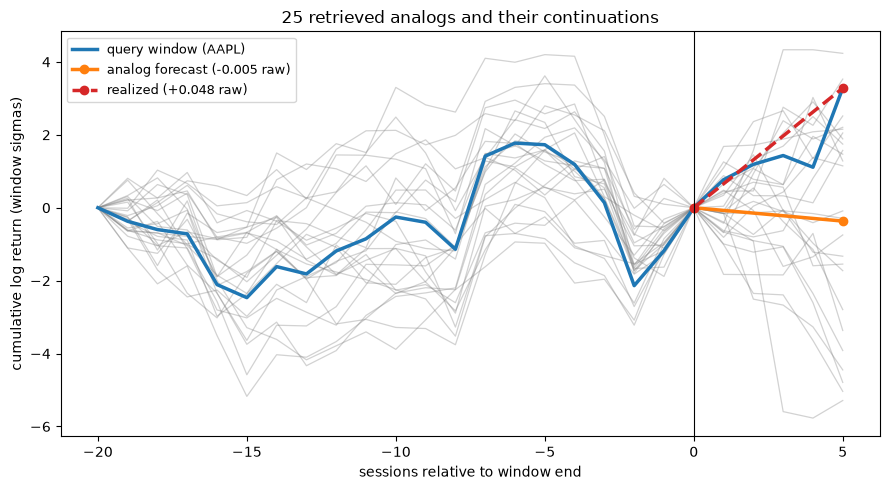

In [9]:
import matplotlib.pyplot as plt

by_symbol = {s: g.sort_values("ts").reset_index(drop=True) for s, g in returns.groupby("symbol")}

def analog_path(symbol: str, window_end: pd.Timestamp, sd: float) -> np.ndarray:
    """Encoded context then realized horizon, in window sigmas, zeroed at the window end."""
    g = by_symbol[symbol]
    t = int(g.index[g["ts"] == window_end][0])
    r = g["logret"].to_numpy()
    context = (r[t - LOOKBACK + 1 : t + 1] - r[t - LOOKBACK + 1 : t + 1].mean()) / sd
    horizon = r[t + 1 : t + 1 + HORIZON] / sd
    return np.concatenate([[0.0], np.cumsum(context), np.cumsum(horizon)])

forecast = predict(neighbours, q_sd)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(-LOOKBACK, HORIZON + 1)
for _, nb in neighbours.iterrows():
    ax.plot(
        x, analog_path(nb["symbol"], nb["window_end"], nb["window_sd"]),
        color="tab:gray", alpha=0.35, lw=0.9,
    )
ax.plot(x, analog_path("AAPL", q_date, q_sd), color="tab:blue", lw=2.5, label="query window (AAPL)")
ax.plot([0, HORIZON], [0, forecast / q_sd], color="tab:orange", lw=2.5, marker="o",
        label=f"analog forecast ({forecast:+.3f} raw)")
ax.plot([0, HORIZON], [0, realized / q_sd], color="tab:red", lw=2.5, ls="--", marker="o",
        label=f"realized ({realized:+.3f} raw)")
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"{TOP_K} retrieved analogs and their continuations")
ax.set_xlabel("sessions relative to window end")
ax.set_ylabel("cumulative log return (window sigmas)")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
print(f"query window vol {q_sd:.4f}/day, forecast {forecast:+.4f}, realized {realized:+.4f}")

The grey fan is the retrieved cases, aligned at the query date. Left of zero
they track the query window closely, which is the retriever doing its job.
Right of zero they run from about minus six sigma to plus four, which is the
honest answer: similar-looking pasts led everywhere.

One draw proves nothing. The forecast is the fan's weighted centre, and the
only way to judge it is over many queries.

## 5. Pricing the leak

Four retrieval rules over the same 149 query dates, same encoder, same top-k.
Only the filter changes.

**A. Whole KB.** No filter at all. The naive vector-store setup.

**B. Exclude the query symbol.** The patch most people write first, on the
theory that the problem is self-retrieval.

**C. `knowable_at <= t`.** The KB bounded to rows whose outcome had already
printed.

**D. Both.** C plus the symbol exclusion, to see whether the patch still adds
anything once the clock is right.

In [10]:
query_idx = list(range(len(aapl) - 750, len(aapl) - HORIZON, 5))

def backtest(leakfree: bool, exclude_self: bool) -> dict:
    preds, actuals = [], []
    for i in query_idx:
        d = aapl["ts"].iloc[i]
        vec, sd = encode(aapl_r[i - LOOKBACK + 1 : i + 1])
        nb = retrieve(
            vec,
            as_of=d.isoformat() if leakfree else None,
            exclude_symbol="AAPL" if exclude_self else None,
        ).to_pandas()
        preds.append(predict(nb, sd))
        actuals.append(float(aapl_r[i + 1 : i + 1 + HORIZON].sum()))
    preds, actuals = np.array(preds), np.array(actuals)
    return {
        "IC": np.corrcoef(preds, actuals)[0, 1],
        "hit_rate": float((np.sign(preds) == np.sign(actuals)).mean()),
    }

variants = {
    "A whole KB": backtest(leakfree=False, exclude_self=False),
    "B exclude own symbol": backtest(leakfree=False, exclude_self=True),
    "C knowable_at <= t": backtest(leakfree=True, exclude_self=False),
    "D both": backtest(leakfree=True, exclude_self=True),
}
noise = 1.0 / np.sqrt(len(query_idx))
print(f"{len(query_idx)} query dates, IC standard error under the null ~{noise:.3f}")
pd.DataFrame(variants).T.round(3)

149 query dates, IC standard error under the null ~0.082


,IC,hit_rate
A whole KB,1.000,1.000
B exclude own symbol,0.170,0.470
C knowable_at <= t,0.032,0.456
D both,0.019,0.450


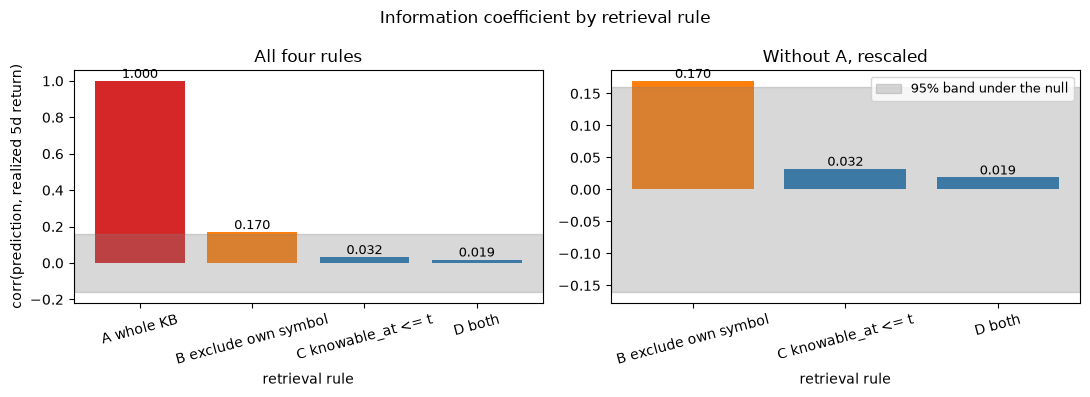

In [11]:
names = list(variants)
ics = [variants[n]["IC"] for n in names]
colors = ["tab:red", "tab:orange", "tab:blue", "tab:blue"]

fig, (ax_all, ax_zoom) = plt.subplots(1, 2, figsize=(11, 4))
for ax, keep, title in (
    (ax_all, slice(0, 4), "All four rules"),
    (ax_zoom, slice(1, 4), "Without A, rescaled"),
):
    ax.bar(names[keep], ics[keep], color=colors[keep])
    ax.axhspan(-1.96 * noise, 1.96 * noise, color="gray", alpha=0.3, label="95% band under the null")
    for x, v in zip(names[keep], ics[keep]):
        ax.text(x, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("retrieval rule")
    ax.tick_params(axis="x", labelrotation=15)
ax_all.set_ylabel("corr(prediction, realized 5d return)")
ax_zoom.legend(fontsize=9)
fig.suptitle("Information coefficient by retrieval rule")
fig.tight_layout()

**A is 1.00.** Not "strong", not "suspicious". Exactly one. The query window
is a row in the knowledge base, its distance to itself is zero, and inverse-
distance weighting hands it essentially all the weight. The retriever looks up
the answer.

**B is the dangerous one.** Excluding the query symbol removes the exact match
and drops the IC to 0.17: positive, just over two standard errors, the sort of
result that survives a slide review. It is still pure leakage. Windows from the
other 29 names ending *after* the query date carry forward returns over the
same calendar sessions AAPL is about to trade through, so the market factor
arrives from the future by another door.

**C is inside the noise band**, which is the honest reading of this experiment.
Twenty-dimensional shape matching over 30 names does not forecast 5-day
returns. The recipe's job was to measure that, not to beat it, and everything
between A and C was infrastructure error rather than alpha.

**D confirms the diagnosis.** Once `knowable_at` bounds the KB, excluding the
query's own symbol changes nothing. Symbol exclusion was a proxy for a
timestamp problem, and proxies fix the case you thought of.

The general point: a vector index has no opinion about time. Bolt one onto a
time series and every retrieval is a lookahead bug waiting to be committed.
Putting the embeddings in a time-series database with the time column set to
*when the label became knowable* makes the correct query the natural one.

## 6. The other clock

`knowable_at` handles event time, the moment a fact became true. It says
nothing about *arrival* time, the moment a row landed in your store. The two
come apart because knowledge-base rows are **derived**. Adjusted closes get
restated after splits and dividends, and a bad print gets corrected, so
rebuilding the KB from today's corpus does not reproduce the rows you served
last year.

Version pinning is that second clock. Every append is a version, and the pin
composes with the `knowable_at` filter rather than replacing it.

In [12]:
at_head = retrieve(q_vec, as_of=q_date.isoformat()).to_pandas()
at_v1 = retrieve(q_vec, as_of=q_date.isoformat(), version=1).to_pandas()

for label, version, got in (("head", db.versions("analogs")[-1], at_head), ("v1", db.versions("analogs")[1], at_v1)):
    print(
        f"KB at {label:<4} {version['rows']:>7,} rows -> {len(got)} neighbours, "
        f"newest knowable_at {got['knowable_at'].max().date()}"
    )

KB at head  63,270 rows -> 25 neighbours, newest knowable_at 2025-07-31
KB at v1    44,520 rows -> 25 neighbours, newest knowable_at 2023-09-05


Both queries ask for the same decision time. The pin wins where it is tighter:
version 1 is the KB before the 2024 append, so its newest usable analog is from
2023 even though the `knowable_at` bound would allow 2025.

On an append-only KB that is the whole difference, and the pin buys
reproducibility rather than correctness. It starts buying correctness the
moment the corpus is restated, because then the *content* of old rows changes
too, not just their number. Recipe
[01/05](../01_market_data_engineering/05_corporate_actions.ipynb) covers
restatement as an audited version, and
[03/02](../03_risk_and_production/02_reproducible_backtests.ipynb) turns a pin
into a reproducible run.

## Scaling past brute force

`array_distance` is exhaustive, and so is the `IndexFlatL2` that TS-RAG uses,
so this is like for like on the metric. It is not like for like on the
constant. FAISS runs its scan as a matmul over a resident matrix, while
DataFusion evaluates a generic Arrow kernel per row.

At 63k rows and 20 dimensions each retrieval here costs tens of milliseconds,
and the `knowable_at` predicate prunes segments before any of it runs. At
millions of segments and 768 dimensions the arithmetic dominates and you want
an approximate index. The split that survives that move is the one already
built here: h5i-db owns the corpus, the labels and the two clocks, and hands a
bounded candidate set to whatever computes the distances.

## Takeaways

- Embeddings are just a column. `pa.list_(pa.float32(), n)` stores a
  fixed-size vector per row, and `array_distance` gives exact L2 top-k in the
  same scan as the filters, with no separate index to keep in sync.
- Timestamp knowledge-base rows by **when the label became knowable**, not when
  the context ended. It turns leakage control into an ordinary time predicate
  that manifest pruning also happens to accelerate.
- Retrieval on time series leaks by default. The naive KB scored an IC of
  1.00, and the obvious patch still scored a plausible, publishable, entirely
  fake 0.17.
- Event time and arrival time are different clocks. `knowable_at` covers the
  first, `db.table(..., version=)` covers the second, and restatements need
  both.
- Deduplicate neighbours before averaging. Overlapping windows of one symbol
  are near-duplicate vectors, so an undeduplicated top-k is one episode with
  false confidence.

In [13]:
db.close()